In [1]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split


In [2]:
from sklearn.utils import resample
import pandas as pd
final_columns = [
    'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK',
    'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'DIABETE3',
    'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY',
    'ASTHMA3', 'ASTHNOW', 'SMOKE100', 'EXERANY2',
    'SEX', '_AGE80', 'INCOME2', 'EDUCA', 'EMPLOY1', '_RACE', '_BMI5',
    '_MICHD'  # 🔴 Target
]


df = pd.read_csv("dataset/2015.csv")
df = df[final_columns]


# Check original distribution
print(df['_MICHD'].value_counts())

# Rename columns

rename_dict = { 
               'BPHIGH4': 'high_bp',
               'BPMEDS': 'bp_meds',
               'BLOODCHO': 'high_chol',
               'CHOLCHK': 'chol_check',
               'CVDINFR4': 'heart_attack',
               'CVDCRHD4': 'coronary_hd',
               'CVDSTRK3': 'stroke',
               'DIABETE3': 'diabetes',
               'CHCCOPD1': 'copd',
               'HAVARTH3': 'arthritis',
               'ADDEPEV2': 'depression',
               'CHCKIDNY': 'kidney_disease',
               'ASTHMA3': 'asthma_ever',
               'ASTHNOW': 'asthma_now',
               'SMOKE100': 'smoker',
               'EXERANY2': 'phys_active', 
               'SEX': 'sex', 
               '_AGE80': 'age',
               'INCOME2': 'income_level',
               'EDUCA': 'education_level',
               'EMPLOY1': 'employment',
               '_RACE': 'race',
               '_BMI5': 'bmi',
               '_MICHD': 'heart_disease' }

df.rename(columns=rename_dict, inplace=True)
df
for col in df.columns:
    print(df[col].value_counts())
    print('-------------------------------')

_MICHD
2.0    398881
1.0     38633
Name: count, dtype: int64
high_bp
3.0    254318
1.0    178188
4.0      4312
2.0      3271
7.0       862
9.0       504
Name: count, dtype: int64
-------------------------------
bp_meds
1.0    149034
2.0     28833
7.0       258
9.0        63
Name: count, dtype: int64
-------------------------------
high_chol
1.0    382302
2.0     49673
7.0      9279
9.0       202
Name: count, dtype: int64
-------------------------------
chol_check
1.0    293355
2.0     43596
3.0     25972
4.0     13523
7.0      5584
9.0       272
Name: count, dtype: int64
-------------------------------
heart_attack
2.0    413755
1.0     25472
7.0      2038
9.0       191
Name: count, dtype: int64
-------------------------------
coronary_hd
2.0    412349
1.0     25290
7.0      3591
9.0       225
Name: count, dtype: int64
-------------------------------
stroke
2.0    421897
1.0     18269
7.0      1146
9.0       144
Name: count, dtype: int64
-------------------------------
diabetes
3.0    

In [3]:
import numpy as np


missing_codes = [7, 9, 77, 99, 777, 999]

df = df.replace(missing_codes, np.nan)


df['high_bp'] = df['high_bp'].replace({1: 1, 3: 0, 2: 1, 4: 1})
df['high_bp'] = df['high_bp'].where(df['high_bp'].isin([0, 1]), np.nan)


df['diabetes'] = df['diabetes'].where(df['diabetes'].isin([1, 2, 3, 4]), np.nan)


df = df.drop(columns=['education_level', 'employment', 'race', 'income_level'
])

# Scale BMI
df['bmi'] = df['bmi'] / 100

# Map target
df['heart_disease'] = df['heart_disease'].map({1: 1, 2: 0})

for col in df.columns:
    print(df[col].value_counts())
    print('-------------------------------')

high_bp
0.0    254318
1.0    185771
Name: count, dtype: int64
-------------------------------
bp_meds
1.0    149034
2.0     28833
Name: count, dtype: int64
-------------------------------
high_chol
1.0    382302
2.0     49673
Name: count, dtype: int64
-------------------------------
chol_check
1.0    293355
2.0     43596
3.0     25972
4.0     13523
Name: count, dtype: int64
-------------------------------
heart_attack
2.0    413755
1.0     25472
Name: count, dtype: int64
-------------------------------
coronary_hd
2.0    412349
1.0     25290
Name: count, dtype: int64
-------------------------------
stroke
2.0    421897
1.0     18269
Name: count, dtype: int64
-------------------------------
diabetes
3.0    372104
1.0     57256
4.0      7690
2.0      3608
Name: count, dtype: int64
-------------------------------
copd
2.0    403586
1.0     35501
Name: count, dtype: int64
-------------------------------
arthritis
2.0    290621
1.0    148036
Name: count, dtype: int64
-----------------------

In [4]:
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns, 'percent_missing': percent_missing})
missing_value_df = missing_value_df.sort_values('percent_missing', ascending=False)
print(missing_value_df)


                   column_name  percent_missing
asthma_now          asthma_now        86.952267
bp_meds                bp_meds        59.709008
chol_check          chol_check        14.726269
phys_active        phys_active         8.606067
bmi                        bmi         8.244989
smoker                  smoker         3.975255
high_chol            high_chol         2.147666
age                        age         1.296845
heart_disease    heart_disease         0.892954
coronary_hd        coronary_hd         0.864639
arthritis            arthritis         0.634038
copd                      copd         0.536633
heart_attack      heart_attack         0.504920
depression          depression         0.497671
kidney_disease  kidney_disease         0.357227
asthma_ever        asthma_ever         0.338199
high_bp                high_bp         0.309657
stroke                  stroke         0.292215
diabetes              diabetes         0.180765
sex                        sex         0

In [5]:
# # Remove all rows with NaN values in any column
# df = df.dropna()

# # Check new shape to see how many rows remain
# print(df.shape)


df = df.drop(columns=['asthma_now','bp_meds','chol_check'])
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns, 'percent_missing': percent_missing})
missing_value_df = missing_value_df.sort_values('percent_missing', ascending=False)
print(missing_value_df)


                   column_name  percent_missing
phys_active        phys_active         8.606067
bmi                        bmi         8.244989
smoker                  smoker         3.975255
high_chol            high_chol         2.147666
age                        age         1.296845
heart_disease    heart_disease         0.892954
coronary_hd        coronary_hd         0.864639
arthritis            arthritis         0.634038
copd                      copd         0.536633
heart_attack      heart_attack         0.504920
depression          depression         0.497671
kidney_disease  kidney_disease         0.357227
asthma_ever        asthma_ever         0.338199
high_bp                high_bp         0.309657
stroke                  stroke         0.292215
diabetes              diabetes         0.180765
sex                        sex         0.000000


In [6]:
# Remove all rows with NaN values in any column
df = df.dropna()
for col in df.columns:
    print(df[col].value_counts())
    print('-------------------------------')

high_bp
0.0    203667
1.0    147949
Name: count, dtype: int64
-------------------------------
high_chol
1.0    312531
2.0     39085
Name: count, dtype: int64
-------------------------------
heart_attack
2.0    331977
1.0     19639
Name: count, dtype: int64
-------------------------------
coronary_hd
2.0    331113
1.0     20503
Name: count, dtype: int64
-------------------------------
stroke
2.0    337597
1.0     14019
Name: count, dtype: int64
-------------------------------
diabetes
3.0    297628
1.0     45133
4.0      6086
2.0      2769
Name: count, dtype: int64
-------------------------------
copd
2.0    323739
1.0     27877
Name: count, dtype: int64
-------------------------------
arthritis
2.0    232631
1.0    118985
Name: count, dtype: int64
-------------------------------
depression
2.0    283784
1.0     67832
Name: count, dtype: int64
-------------------------------
kidney_disease
2.0    339264
1.0     12352
Name: count, dtype: int64
-------------------------------
asthma_ever


In [7]:
# Directly bin ages into int codes
df['age_cat'] = pd.cut(
    df['age'],
    bins=[0, 40, 60, 120],
    labels=[0, 1, 2]  # Assign category codes directly
).astype(int)



# --- Interaction features
df['age_x_bp'] = df['age'] * df['high_bp']

df['age_x_diab'] = df['age'] * df['diabetes']

# --- Chronic disease count
chronic_cols = ['high_bp', 'diabetes', 'arthritis', 'stroke', 'copd', 'kidney_disease', 'high_chol']
df['chronic_count'] = df[chronic_cols].sum(axis=1)



# Square and cube of age to capture risk acceleration
df['age_sq'] = df['age'] ** 2

df['age_cu'] = df['age'] ** 3

# Log-transform to compress skewed distribution and highlight relative changes
df['age_log'] = np.log1p(df['age'])


# Cardiovascular Risk Index: average of major risk conditions
cardio_cols = ['high_bp', 'high_chol', 'diabetes', 'stroke']
df['cv_risk_index'] = df[cardio_cols].mean(axis=1)

# Respiratory Risk Index: COPD and asthma history
resp_cols = ['copd', 'asthma_ever']
df['resp_risk_index'] = df[resp_cols].mean(axis=1)

# Chronic Disease Burden: count of all chronic conditions (enhances existing chronic_count)
all_chronic = ['high_bp','high_chol','diabetes','stroke','copd','arthritis','kidney_disease','depression','asthma_ever']
df['burden_index'] = df[all_chronic].sum(axis=1) / len(all_chronic)


# Age × major risk factors
df['age_x_cv'] = df['age'] * df['cv_risk_index']

# Three-way interaction: age, BP, and diabetes
df['age_bp_diab'] = df['age'] * df['high_bp'] * df['diabetes']

# BMI-age interaction to reflect weight risk at different ages
df['bmi_x_age'] = df['bmi'] * df['age']



# BMI transformations
df['bmi_log'] = np.log1p(df['bmi'])

df['bmi_sqrt'] = np.sqrt(df['bmi'])



# Replace or remove problematic characters in feature names for XGBoost compatibility
df.columns = df.columns.str.replace('[<>\\[\\]]', '', regex=True)

df.head()


,high_bp,high_chol,heart_attack,coronary_hd,stroke,diabetes,copd,arthritis,depression,kidney_disease,...,age_cu,age_log,cv_risk_index,resp_risk_index,burden_index,age_x_cv,age_bp_diab,bmi_x_age,bmi_log,bmi_sqrt
0,1.0,1.0,2.0,2.0,2.0,3.0,1.0,1.0,1.0,2.0,...,250047.0,4.158883,1.75,1.0,1.444444,110.25,189.0,2531.34,3.717953,6.338770
1,0.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,...,140608.0,3.970292,1.50,2.0,1.777778,78.00,0.0,1304.68,3.261552,5.008992
3,1.0,1.0,2.0,2.0,2.0,3.0,2.0,1.0,1.0,2.0,...,250047.0,4.158883,1.75,2.0,1.666667,110.25,189.0,1775.97,3.373826,5.309426
4,0.0,1.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,...,226981.0,4.127134,1.50,2.0,1.666667,91.50,0.0,1486.57,3.233567,4.936598
5,1.0,1.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,...,389017.0,4.304065,1.75,2.0,1.777778,127.75,219.0,1935.96,3.314913,5.149757


In [8]:
# X = df.drop(columns = ['heart_disease','heart_attack','coronary_hd'], axis=1)


X = df.drop(columns=['heart_disease', 'heart_attack', 'coronary_hd'], axis=1)


y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# more feature engineering.

import pandas as pd
import numpy as np




In [9]:
# UNDERSAMPLING JUST THE TRAIN SET KEEPING TEST SET AS IT IS




# -----------------------------
# 2. Combine X_train & y_train for resampling
# -----------------------------
train_df = pd.concat([X_train, y_train], axis=1)

# -----------------------------
# 3. Separate classes in TRAIN only
# -----------------------------
df_majority = train_df[train_df['heart_disease'] == 0]
df_minority = train_df[train_df['heart_disease'] == 1]

# -----------------------------
# 4. Downsample majority class
# -----------------------------
df_majority_downsampled = resample(
    df_majority,
    replace=False,                  # no replacement
    n_samples=len(df_minority),     # match minority class
    random_state=42
)

# -----------------------------
# 5. Merge and shuffle
# -----------------------------
train_balanced = pd.concat([df_majority_downsampled, df_minority])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Final training sets
X_train = train_balanced.drop(columns=['heart_disease'])
y_train = train_balanced['heart_disease']

# Test set stays imbalanced naturally:
print("Train dist:\n", y_train.value_counts())
print("Test dist:\n", y_test.value_counts())

Train dist:
 heart_disease
0    24146
1    24146
Name: count, dtype: int64
Test dist:
 heart_disease
0    64287
1     6037
Name: count, dtype: int64


In [10]:
# MULTIPLE MODELS




from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score

def evaluate_models(X_train, X_test, y_train, y_test):
    # Models with default sklearn / XGBoost / LightGBM settings
    models = {
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=500, solver='liblinear'),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        "LightGBM": LGBMClassifier(random_state=42)
    }

    results = []

    for name, model in models.items():
        print(f"\n{name}")
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Metrics
        cm = confusion_matrix(y_test, y_pred)
        report_str = classification_report(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", report_str)
        print("ROC AUC:", auc)
        
        results.append({
            "Model": name,
            "Accuracy": (y_pred == y_test).mean(),
            "Recall_1": recall_score(y_test, y_pred, pos_label=1),
            "Precision_1": precision_score(y_test, y_pred, pos_label=1),
            "F1_1": f1_score(y_test, y_pred, pos_label=1),
            "ROC_AUC": auc
        })

    return pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df = evaluate_models(X_train, X_test, y_train, y_test)
print("\nSummary Table:")
print(results_df)


Gradient Boosting
Confusion Matrix:
 [[45496 18791]
 [ 1153  4884]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.71      0.82     64287
           1       0.21      0.81      0.33      6037

    accuracy                           0.72     70324
   macro avg       0.59      0.76      0.57     70324
weighted avg       0.91      0.72      0.78     70324

ROC AUC: 0.8367739526846774

Random Forest
Confusion Matrix:
 [[44900 19387]
 [ 1538  4499]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.70      0.81     64287
           1       0.19      0.75      0.30      6037

    accuracy                           0.70     70324
   macro avg       0.58      0.72      0.56     70324
weighted avg       0.90      0.70      0.77     70324

ROC AUC: 0.7903171574173656

Logistic Regression
Confusion Matrix:
 [[45251 19036]
 [ 1659  4378]]
Classification Report:
              

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:23:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[45369 18918]
 [ 1208  4829]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.71      0.82     64287
           1       0.20      0.80      0.32      6037

    accuracy                           0.71     70324
   macro avg       0.59      0.75      0.57     70324
weighted avg       0.91      0.71      0.78     70324

ROC AUC: 0.8288398323837767

LightGBM
[LightGBM] [Info] Number of positive: 24146, number of negative: 24146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 48292, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Confusion Matrix:
 [[45377 18910]
 [ 1134  4903]]
Classifi

In [12]:
# CATBOOST MODEL


from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize with class weights to prioritize recall
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.01,
    depth=8,
    eval_metric='F1',
    random_seed=42,
    verbose=50,
    l2_leaf_reg=5
)

# Fit on the same training data
cat.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Evaluate at default threshold 0.5
y_pred_cat = cat.predict(X_test)
y_prob_cat = cat.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob_cat))


0:	learn: 0.7628443	test: 0.3010648	best: 0.3010648 (0)	total: 174ms	remaining: 1m 26s
50:	learn: 0.7723445	test: 0.3200310	best: 0.3200310 (50)	total: 1.84s	remaining: 16.2s
100:	learn: 0.7734701	test: 0.3218781	best: 0.3218781 (100)	total: 3.5s	remaining: 13.8s
150:	learn: 0.7751698	test: 0.3240059	best: 0.3242111 (146)	total: 4.95s	remaining: 11.5s
200:	learn: 0.7763439	test: 0.3241508	best: 0.3243137 (198)	total: 6.43s	remaining: 9.57s
250:	learn: 0.7767150	test: 0.3253384	best: 0.3255478 (247)	total: 7.77s	remaining: 7.71s
300:	learn: 0.7772895	test: 0.3259001	best: 0.3259659 (299)	total: 9.14s	remaining: 6.04s
350:	learn: 0.7779261	test: 0.3259880	best: 0.3261672 (340)	total: 10.4s	remaining: 4.43s
400:	learn: 0.7784386	test: 0.3263756	best: 0.3265993 (385)	total: 11.7s	remaining: 2.88s
450:	learn: 0.7795405	test: 0.3268735	best: 0.3269841 (444)	total: 12.8s	remaining: 1.39s
499:	learn: 0.7803489	test: 0.3272089	best: 0.3273425 (486)	total: 13.9s	remaining: 0us

bestTest = 0.3273


Training Gradient Boosting...

Training Bayesian GBM...

Training Ensemble...

Training Logistic Regression...

Training LightGBM...
[LightGBM] [Info] Number of positive: 24146, number of negative: 24146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 48292, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Training XGBoost...


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:30:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training Stacking Ensemble...

Training CatBoost...


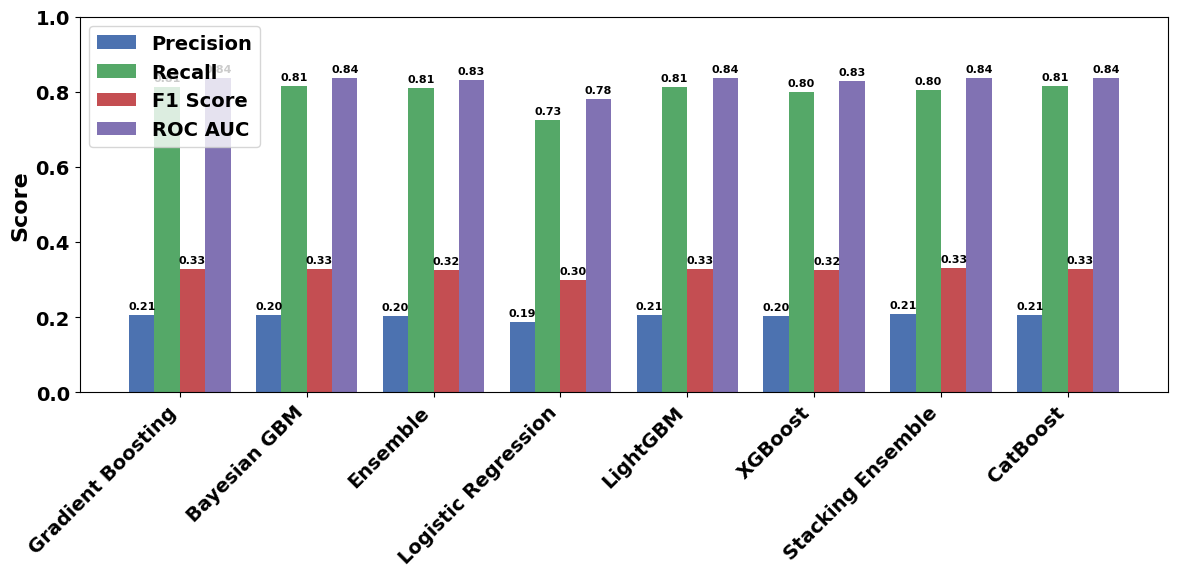

In [13]:
# DEFAULT THRESHOLD


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# ------------------------

import matplotlib.pyplot as plt

# Set global font styles
plt.rcParams.update({
    # Base font
    'font.size': 14,            # global default text size
    'font.weight': 'bold',      # global default text weight

    # Axes
    'axes.titlesize': 18,       # axes title size
    'axes.titleweight': 'bold',
    'axes.labelsize': 16,       # x/y label size
    'axes.labelweight': 'bold',

    # Ticks
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # Legend
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,

    # Figure
    'figure.titlesize': 20,     # figure suptitle size
})


# ------------------------
 # for GradientBoosting



# ====== 2. Define models with balancing ======
models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.03, max_depth=4,
        min_samples_split=5, min_samples_leaf=1,
        subsample=0.8, max_features=None, random_state=42
    ),  # sample_weight at fit()

    "Bayesian GBM": GradientBoostingClassifier(
        n_estimators=330, learning_rate=0.01392212, max_depth=5,
        min_samples_split=20, min_samples_leaf=10,
        subsample=1.0, max_features=0.3, random_state=42
    ),  # sample_weight at fit()

    "Ensemble": VotingClassifier(
        estimators=[
            ("gb", GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.03, max_depth=4,
                min_samples_split=5, min_samples_leaf=1,
                subsample=0.8, max_features=None, random_state=42
            )),
            ("lgb", LGBMClassifier(random_state=42)),
            ("lr", LogisticRegression(max_iter=500, solver="liblinear"))
        ],
        voting="soft", n_jobs=-1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=500, solver="liblinear", random_state=42
    ),

    "LightGBM": LGBMClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42, eval_metric="logloss", use_label_encoder=False
    ),

    "Stacking Ensemble": None,  # will define after

    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        eval_metric="F1", random_seed=42, verbose=False
    )
}

# ====== 3. Define stacking ensemble ======
base_models = [
    ("gb_bayes", models["Bayesian GBM"]),
    ("lgb", models["LightGBM"]),
    ("xgb", models["XGBoost"]),
    ("lr", models["Logistic Regression"])
]
models["Stacking Ensemble"] = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=500),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1,
    verbose=0
)

# ====== 4. Train each model and collect metrics ======
metrics = {"Model": [], "Precision": [], "Recall": [], "F1": [], "ROC_AUC": []}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if "Gradient Boosting" in name:  # both GBMs use sample_weight
        model.fit(X_train, y_train)
    elif name == "Ensemble":
        # Ensemble has GB inside without class_weight — so we pass normal fit
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics["Model"].append(name)
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))
    metrics["F1"].append(f1_score(y_test, y_pred))
    metrics["ROC_AUC"].append(roc_auc_score(y_test, y_prob))

# ====== 5. Convert to DataFrame ======
metrics_df = pd.DataFrame(metrics)

# ====== 6. Plot grouped bar chart ======
labels = metrics_df["Model"]
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - 1.5*width, metrics_df["Precision"], width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x - 0.5*width, metrics_df["Recall"],    width, label='Recall',    color='#55A868')
rects3 = ax.bar(x + 0.5*width, metrics_df["F1"],        width, label='F1 Score',  color='#C44E52')
rects4 = ax.bar(x + 1.5*width, metrics_df["ROC_AUC"],   width, label='ROC AUC',   color='#8172B3')

ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper left')

def annotate(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

for rects in [rects1, rects2, rects3, rects4]:
    annotate(rects)

plt.tight_layout()
plt.show()


[LightGBM] [Info] Number of positive: 24146, number of negative: 24146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 48292, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:33:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


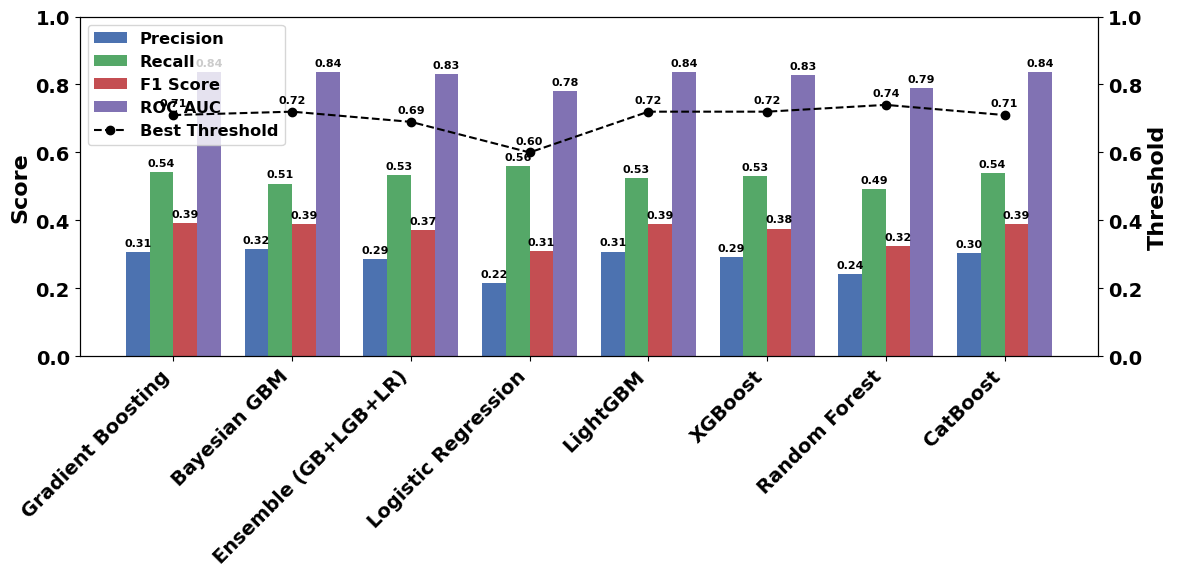

In [14]:

# Plotting the metrices with threshold optimization

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_fscore_support



# Set global font styles
plt.rcParams.update({
    # Base font
    'font.size': 14,            # global default text size
    'font.weight': 'bold',      # global default text weight

    # Axes
    'axes.titlesize': 18,       # axes title size
    'axes.titleweight': 'bold',
    'axes.labelsize': 16,       # x/y label size
    'axes.labelweight': 'bold',

    # Ticks
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # Legend
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,

    # Figure
    'figure.titlesize': 20,     # figure suptitle size
})



# 1. Define models with tuned hyperparameters
models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.03, max_depth=4,
        min_samples_split=5, min_samples_leaf=1,
        subsample=0.8, max_features=None, random_state=42
    ),
    "Bayesian GBM": GradientBoostingClassifier(
        n_estimators=330, learning_rate=0.01392212, max_depth=5,
        min_samples_split=20, min_samples_leaf=10,
        subsample=1.0, max_features=0.3, random_state=42
    ),
    "Ensemble (GB+LGB+LR)": VotingClassifier(
        estimators=[
            ("gb", GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.03, max_depth=4,
                min_samples_split=5, min_samples_leaf=1,
                subsample=0.8, max_features=None, random_state=42
            )),
            ("lgb", LGBMClassifier(random_state=42)),
            ("lr", LogisticRegression(max_iter=500, solver="liblinear"))
        ],
        voting="soft", n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="liblinear", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False),
    "Random Forest": RandomForestClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        eval_metric="F1", random_seed=42, verbose=False
    )
}

# 2. Train, compute best threshold and metrics
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    # find best threshold
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_prob >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    # metrics at best threshold
    y_pred_best = (y_prob >= best_t).astype(int)
    results[name] = {
        "Threshold": best_t,
        "Precision": precision_score(y_test, y_pred_best),
        "Recall":    recall_score(y_test, y_pred_best),
        "F1":        f1_score(y_test, y_pred_best),
        "ROC_AUC":   roc_auc_score(y_test, y_prob)
    }

# 3. Prepare data for plotting
models_list = list(results.keys())
precision_vals = [results[m]["Precision"] for m in models_list]
recall_vals    = [results[m]["Recall"]    for m in models_list]
f1_vals        = [results[m]["F1"]        for m in models_list]
auc_vals       = [results[m]["ROC_AUC"]    for m in models_list]
threshold_vals = [results[m]["Threshold"]  for m in models_list]

x = np.arange(len(models_list))
width = 0.2

# 4. Plot metrics as grouped bars and thresholds as a line
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars for metrics
bars1 = ax1.bar(x - 1.5*width, precision_vals, width, label='Precision', color='#4C72B0')
bars2 = ax1.bar(x - 0.5*width, recall_vals,    width, label='Recall',    color='#55A868')
bars3 = ax1.bar(x + 0.5*width, f1_vals,        width, label='F1 Score',  color='#C44E52')
bars4 = ax1.bar(x + 1.5*width, auc_vals,      width, label='ROC AUC',   color='#8172B3')

ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.set_ylim(0.0, 1.0)

# Secondary axis for threshold
ax2 = ax1.twinx()
ax2.plot(x, threshold_vals, color='black', marker='o', linestyle='--', label='Best Threshold')
ax2.set_ylabel('Threshold')
ax2.set_ylim(0.0, 1.0)

# Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize='small')

# Annotate bars
def annotate_bars(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

for b in [bars1, bars2, bars3, bars4]:
    annotate_bars(b, ax1)

# Annotate threshold points
for xi, t in zip(x, threshold_vals):
    ax2.annotate(f'{t:.2f}', xy=(xi, t), xytext=(0, 5),
                 textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


[LightGBM] [Info] Number of positive: 24146, number of negative: 24146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 48292, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:35:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


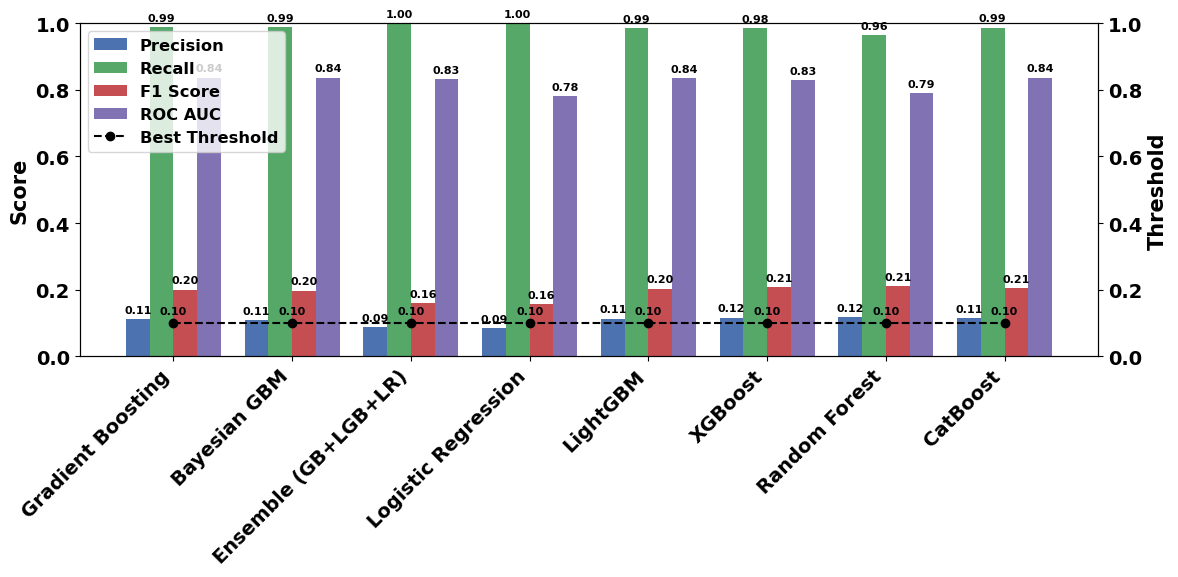

In [15]:
# Plotting the metrices with threshold optimization

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_fscore_support


# Set global font styles
plt.rcParams.update({
    # Base font
    'font.size': 14,            # global default text size
    'font.weight': 'bold',      # global default text weight

    # Axes
    'axes.titlesize': 15,       # axes title size
    'axes.titleweight': 'bold',
    'axes.labelsize': 15,       # x/y label size
    'axes.labelweight': 'bold',

    # Ticks
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # Legend
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,

    # Figure
    'figure.titlesize': 20,     # figure suptitle size
})





# 1. Define models with tuned hyperparameters
models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.03, max_depth=4,
        min_samples_split=5, min_samples_leaf=1,
        subsample=0.8, max_features=None, random_state=42
    ),
    "Bayesian GBM": GradientBoostingClassifier(
        n_estimators=330, learning_rate=0.01392212, max_depth=5,
        min_samples_split=20, min_samples_leaf=10,
        subsample=1.0, max_features=0.3, random_state=42
    ),
    "Ensemble (GB+LGB+LR)": VotingClassifier(
        estimators=[
            ("gb", GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.03, max_depth=4,
                min_samples_split=5, min_samples_leaf=1,
                subsample=0.8, max_features=None, random_state=42
            )),
            ("lgb", LGBMClassifier(random_state=42)),
            ("lr", LogisticRegression(max_iter=500, solver="liblinear"))
        ],
        voting="soft", n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="liblinear", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False),
    "Random Forest": RandomForestClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        eval_metric="F1", random_seed=42, verbose=False
    )
}

# 2. Train, compute best threshold and metrics
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    # find best threshold
    # find best threshold (max recall instead of max F1)
    best_recall, best_t = 0, 0.5
    for t in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_prob >= t).astype(int)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        if rec > best_recall:       # <-- change here
            best_recall, best_t = rec, t

    # metrics at best threshold
    y_pred_best = (y_prob >= best_t).astype(int)
    results[name] = {
        "Threshold": best_t,
        "Precision": precision_score(y_test, y_pred_best, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_best, zero_division=0),
        "F1":        f1_score(y_test, y_pred_best, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_test, y_prob)
    }


# 3. Prepare data for plotting
models_list = list(results.keys())
precision_vals = [results[m]["Precision"] for m in models_list]
recall_vals    = [results[m]["Recall"]    for m in models_list]
f1_vals        = [results[m]["F1"]        for m in models_list]
auc_vals       = [results[m]["ROC_AUC"]    for m in models_list]
threshold_vals = [results[m]["Threshold"]  for m in models_list]

x = np.arange(len(models_list))
width = 0.2

# 4. Plot metrics as grouped bars and thresholds as a line
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars for metrics
bars1 = ax1.bar(x - 1.5*width, precision_vals, width, label='Precision', color='#4C72B0')
bars2 = ax1.bar(x - 0.5*width, recall_vals,    width, label='Recall',    color='#55A868')
bars3 = ax1.bar(x + 0.5*width, f1_vals,        width, label='F1 Score',  color='#C44E52')
bars4 = ax1.bar(x + 1.5*width, auc_vals,      width, label='ROC AUC',   color='#8172B3')

ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=45, ha='right')

ax1.set_ylim(0.0, 1.0)

# Secondary axis for threshold
ax2 = ax1.twinx()
ax2.plot(x, threshold_vals, color='black', marker='o', linestyle='--', label='Best Threshold')
ax2.set_ylabel('Threshold')
ax2.set_ylim(0.0, 1.0)

# Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize='small')

# Annotate bars
def annotate_bars(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

for b in [bars1, bars2, bars3, bars4]:
    annotate_bars(b, ax1)

# Annotate threshold points
for xi, t in zip(x, threshold_vals):
    ax2.annotate(f'{t:.2f}', xy=(xi, t), xytext=(0, 5),
                 textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
